In [1]:
pip install pandas pyarrow # Para ler o arquivo .parquet deszipado

Note: you may need to restart the kernel to use updated packages.


# Projeto de Mineração de Dados 

**Disciplina:** Mineração de Dados  
**Grupo:** João Marcos Oliveira Neves (2024008644), Júlia Borba Fonseca de Souza (2023117580), Laura Martins Froede (2023087877), Matheus Soares dos Santos de Freitas (2024080043) 
**Dataset:**  Instacart Market Basket Analysis

---

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | Instacart Market Basket Analysis |
| Link público do dataset | https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis |
| Número de linhas | 3.240.459 |
| Número de colunas | 15 |
| Tarefa principal de mineração | Mineração de Padrões Frequentes |
| Tarefa secundária de mineração | Classificação |

# 1. Business Understanding

## 1.1 Problema de negócio e objetivo analítico

* **Contexto:** O Instacart é um serviço americano de entrega de compras no mesmo dia. No setor de e-commerce de supermercados (*online grocery*), a retenção de clientes depende drasticamente da conveniência e da velocidade com que o usuário consegue reabastecer sua despensa. O ato de refazer compras é altamente rotineiro (laticínios, hortifrúti), gerando um volume transacional massivo e recorrente.
* **Problema:** À medida que o portfólio de produtos cresce, os usuários enfrentam fricção cognitiva para localizar e selecionar manualmente dezenas de itens que compram regularmente, o que pode levar ao abandono do carrinho ou à redução do tamanho da cesta. Métodos tradicionais de recomendação falham em capturar de forma conjunta a sazonalidade individual e a sinergia de afinidade entre os produtos comprados simultaneamente.
* **Objetivo analítico:** Desenvolver uma abordagem preditiva híbrida estruturada em duas frentes: (1) mineração de padrões frequentes utilizando o algoritmo **FP-Growth** sobre o histórico transacional para gerar atributos de afinidade e regras de associação, e (2) um modelo de classificação supervisionada focado em predizer a probabilidade de recompra de um par específico `(user_id, product_id)` na próxima janela de compra.
* **Usuários ou interessados:** A equipe de Engenharia de Produto, o time de Growth Marketing e os Gestores de Categoria de Negócio da plataforma de e-commerce.
* **Decisões apoiadas:** Personalização dinâmica da interface do usuário (ex: ordenação inteligente da seção *"Buy It Again"*), otimização de campanhas de CRM baseadas na recência prevista de esgotamento de produtos perecíveis e estratégias de cross-selling de alta conversão no momento do checkout.

---

## 1.2 Dataset, origem e características finais

##### Identificação do dataset

* **Nome:** Instacart Market Basket Analysis
* **Fonte:** Kaggle
* **Link público:** [https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis](https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis)
* **Data de acesso ou download:** 28/04/2026

##### Características gerais

* **O que cada linha representa?** Um produto específico que foi incluído em um determinado pedido feito por um usuário.
* **O que cada coluna representa?** Metadados do pedido (IDs, horário, dia da semana, intervalo de dias), metadados do produto (nome, corredor, departamento) e indicadores operacionais (ordem de inserção na cesta e flag de recompra).
* **Número de instâncias:** 3.240.459 (na amostra *prior* utilizada).
* **Número de atributos:** 15 colunas.
* **Tipos principais de atributos:** Numéricos discretos/contínuos, categóricos e textuais estruturados.
* **Existe variável-alvo?** **SIM**. A coluna `reordered` (binária), que mapeia se o item já foi comprado pelo usuário anteriormente (1) ou se é adicionado pela primeira vez (0).
* **Existem atributos sensíveis ou identificadores?** **SIM**. Há chaves identificadoras relacionais (`user_id`, `order_id`, `product_id`, `aisle_id`, `department_id`). Não existem atributos de cunho sensível ou de identificação pessoal direta (PII), mantendo o anonimato biográfico dos consumidores.

##### Estratégia de Amostragem e Alinhamento Temporal

Devido à dimensão massiva do ecossistema original do Instacart (que ultrapassa 32 milhões de registros transacionais), inviabilizando ciclos ágeis de experimentação em ambientes locais de computação, foi adotada uma estratégia de **Amostragem Estratificada Baseada em Usuários**.

Em vez de amostrar linhas soltas de forma puramente aleatória — o que quebraria o histórico temporal e a composição das cestas de compras —, o processo foi estruturado em três etapas garantindo consistência e representatividade:

1. **Isolamento de Identificadores:** Sorteou-se deterministicamente uma fração de 10% dos identificadores únicos de usuários (`user_id`).
2. **Mapeamento e Pareamento 1-1:** Para garantir que cada usuário selecionado tivesse seu histórico completo preservado e sua respectiva resposta futura alinhada, os IDs amostrados foram mapeados simultaneamente nas bases `prior` e `train` por meio de uma operação de junção interna (`inner join` via restrição de chave), equivalente à lógica computacional:

$$\text{df\_prior\_amostra} = \text{df\_prior}[\text{ids\_amostrados, on} = \text{"user\_id"}, \text{nomatch} = 0]$$


$$\text{df\_train\_amostra} = \text{df\_train}[\text{ids\_amostrados, on} = \text{"user\_id"}, \text{nomatch} = 0]$$


3. **Validação de Representatividade Categórica (Departamentos):** Para provar que a amostra de 10% é estatisticamente representativa da população original, validou-se que a proporção volumétrica de vendas de cada macrocategoria (`department`) permaneceu rigorosamente invariante entre a base total e a base amostrada (por exemplo, o departamento *Produce* manteve exatamente o mesmo percentual de relevância nas duas frentes), eliminando vieses de seleção e garantindo a generalização dos padrões de afinidade descobertos pelo algoritmo FP-Growth.

##### Dicionário de dados

Abaixo está o mapeamento técnico exato das variáveis presentes na amostra do seu notebook:

| Coluna | Tipo | Descrição | Papel na análise | Observações |
| --- | --- | --- | --- | --- |
| `order_id` | `int32` | Identificador único de cada pedido. | **ID / Agrupador** | Essencial para agrupar as cestas antes de rodar o FP-Growth. |
| `user_id` | `int32` | Identificador único de cada cliente. | **ID / Chave** | Base para calcular perfis comportamentais e granularidade da predição. |
| `eval_set` | `object` | Avaliação da partição (ex: *prior*). | **Removida** | Possui valor único fixo na amostra transacional analisada. |
| `order_number` | `int32` | Número sequencial do pedido por usuário. | **Feature** | Indica o nível de maturidade/fidelidade do cliente na plataforma. |
| `order_dow` | `int32` | Dia da semana em que o pedido foi feito (0 a 6). | **Feature** | Captura sazonalidade semanal de compras (ex: feira de hortifrúti). |
| `order_hour_of_day` | `int32` | Hora do dia em que o pedido foi feito (0 a 23). | **Feature** | Mapeia picos de comportamento intradiário dos usuários. |
| `days_since_prior_order` | `float64` | Dias decorridos desde o último pedido do usuário. | **Feature** | Indicador direto de recência. Contém nulos na primeira compra. |
| `product_id` | `int32` | Identificador único do produto. | **ID / Chave** | Parte da chave primária do problema alvo `(user_id, product_id)`. |
| `add_to_cart_order` | `int32` | Ordem sequencial de inserção do item no carrinho. | **Feature** | Reflete a prioridade mental do item na mente do consumidor. |
| `reordered` | `int32` | Flag binária indicando se o item é uma recompra (0 ou 1). | **Alvo (Target)** | Variável dependente a ser predita pelo classificador. |
| `product_name` | `object` | Nome textual de exibição do produto. | **Metadado** | Utilizado para auditoria de regras e garantir a explicabilidade. |
| `aisle_id` | `int32` | Identificador numérico do corredor do produto. | **Feature** | Reduz a dimensionalidade mapeando categorias intermediárias. |
| `department_id` | `int32` | Identificador numérico do departamento. | **Feature** | Variável estrutural categórica de agrupamento macro. |
| `aisle` | `object` | Descrição textual do corredor (ex: *packaged vegetables fruits*). | **Metadado** | Fornece contexto legível para humanos nas predições. |
| `department` | `object` | Descrição textual do departamento (ex: *produce*). | **Metadado** | Fundamental para a análise qualitativa de viés e explicabilidade. |

## 1.3 Diretrizes de IA responsável e pertinência ao problema

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
| --- | --- | --- | --- |
| **Explicabilidade (*Explainability*)** | Sistemas black-box que geram recomendações frias reduzem a confiança dos stakeholders e dos usuários. É indispensável entender *por que* um par usuário-produto possui alta propensão de recompra. | A solução final foi desenhada para extrair metadados inteligíveis (`department`, `aisle`, `product_name`) e mesclá-los com regras explícitas geradas pelo FP-Growth (Métricas de *Lift* e *Confiança*). Isso permite auditar o modelo e criar justificativas comerciais claras para as recomendações. | Inclusão de recursos explícitos de taxonomia textual na EDA e na estruturação lógica das regras de associação no notebook, garantindo que o comportamento final do pipeline seja interpretável por humanos. |
| **Eficiência Sustentável e Solução Econômica (*Mineração Ágil*)** | O processamento transacional de tabelas com milhões de linhas pode estourar as limitações de memória RAM, inviabilizando modelos em tempo real e gerando alto custo computacional de infraestrutura. | Influenciou na arquitetura de amostragem controlada de dados e na tipagem otimizada das variáveis para `int32` e `float64` via formato Parquet. Além disso, determinou a aplicação de filtros estritos de suporte mínimo no FP-Growth para focar o poder computacional nos padrões estatisticamente robustos. | Logs estruturados no notebook demonstrando o uso eficiente de memória com a amostra em formato Parquet (`df_prior_amostra.parquet`) de ~3,24 milhões de linhas, provando o trade-off controlado entre o uso de hardware e a retenção de conhecimento. |

# 2. Data Understanding & Data Preparation

## 2.1 Exploração inicial

In [9]:
import pandas as pd

# Dados do histórico de compras (prior)

# Caminho para o seu arquivo .parquet
caminho_arquivo = "/home/matheus/TPs-Mineracao-de-Dados/data/data_project/df_prior_amostra.parquet"

# Lendo o dataframe
df_prior_amostra= pd.read_parquet(caminho_arquivo)

# Exibindo informações básicas da base
print(f"Linhas: {df_prior_amostra.shape[0]}")
print(f"Colunas: {df_prior_amostra.shape[1]}")
display(df_prior_amostra.head())

,product_id,order_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id,product_name,department,aisle
0,1080,2289755,8,0,33026,prior,13,0,9,8.0,123,4,"Salad, Cobb",produce,packaged vegetables fruits
1,1197,493282,1,0,33026,prior,10,1,0,5.0,111,17,"Plates, Ultra, 10-1/16 Inch",household,plates bowls cups flatware
2,1197,3161380,4,1,33026,prior,11,5,19,4.0,111,17,"Plates, Ultra, 10-1/16 Inch",household,plates bowls cups flatware
3,1263,2804480,8,0,33026,prior,16,6,16,18.0,21,16,American Cheese Slices 12 Count,dairy eggs,packaged cheese
4,1541,493282,5,1,33026,prior,10,1,0,5.0,86,16,Jumbo Grade A Eggs,dairy eggs,eggs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3240454,46949,1662762,10,1,167503,prior,4,3,11,18.0,100,21,Eat Your Colors Reds Puree Baby Food,missing,missing
3240455,46949,2777660,5,1,167503,prior,6,2,18,8.0,100,21,Eat Your Colors Reds Puree Baby Food,missing,missing
3240456,46949,2911473,6,1,167503,prior,8,5,15,5.0,100,21,Eat Your Colors Reds Puree Baby Food,missing,missing
3240457,46949,3280566,6,1,167503,prior,9,1,13,10.0,100,21,Eat Your Colors Reds Puree Baby Food,missing,missing


In [22]:
# Dados da última cesta de compras

# Caminho para o seu arquivo .parquet
caminho_arquivo = "/home/matheus/TPs-Mineracao-de-Dados/data/data_project/df_train_amostra.parquet"

# Lendo o dataframe
df_train_amostra= pd.read_parquet(caminho_arquivo)

# Exibindo informações básicas da base
print(f"Linhas: {df_train_amostra.shape[0]}")
print(f"Colunas: {df_train_amostra.shape[1]}")
display(df_train_amostra.head())

Linhas: 139038
Colunas: 15


,product_id,order_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id,product_name,department,aisle
0,7751,1300999,1,1,13342,train,15,0,12,4.0,72,13,Tomato Ketchup,pantry,condiments
1,18019,1300999,3,1,13342,train,15,0,12,4.0,4,9,Macaroni & Cheese Dinner Original Flavor,dry goods pasta,instant foods
2,36772,1300999,4,0,13342,train,15,0,12,4.0,4,9,Bunny Pasta with Yummy Cheese Macaroni & Cheese,dry goods pasta,instant foods
3,40709,1300999,6,0,13342,train,15,0,12,4.0,107,19,Sea Salt & Vinegar Potato Chips,snacks,chips pretzels
4,46175,1300999,5,0,13342,train,15,0,12,4.0,37,1,Half Baked® Ice Cream,frozen,ice cream ice


In [11]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis?select=orders.csv",
            "atende": "True"
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df_prior_amostra))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,3240459,True
1,Mínimo de 4 colunas,15,True
2,Dataset publicamente acessível,https://www.kaggle.com/datasets/psparks/instac...,True


In [12]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df_prior_amostra)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
days_since_prior_order,float64,207017,6.39,31,8.0
order_id,int32,0,0.00,322154,2289755
product_id,int32,0,0.00,41459,1080
product_name,object,0,0.00,41459,"Salad, Cobb"
user_id,int32,0,0.00,20621,33026
aisle_id,int32,0,0.00,134,123
aisle,object,0,0.00,134,packaged vegetables fruits
add_to_cart_order,int32,0,0.00,102,8
order_number,int32,0,0.00,99,13
order_hour_of_day,int32,0,0.00,24,9


### Análise dos Resultados: 
A partir do diagnóstico estrutural executado sobre a amostra dos dados transacionais do e-commerce, extraem-se as seguintes conclusões fundamentais para a caracterização do ecossistema de modelagem:

* **Quantidade de linhas e colunas:** O conjunto de dados cumpre com folga os pré-requisitos do projeto, apresentando uma estrutura massiva composta por **3.240.459 linhas (instâncias)** e **15 colunas (atributos)**. Essa escala garante representatividade estatística tanto para o treinamento de regras de associação quanto para os modelos de classificação. A volumetria de 3.240.459 linhas observada no diagnóstico estrutural é o resultado direto da amostragem de 10% dos usuários com mapeamento biunívoco (1-1) entre o histórico (`prior`) e o alvo de teste (`train`). Conforme validado na análise de aderência, a manutenção exata das proporções originais por departamento garante que as regras de associação extraídas nesta fase exploratória reflitam com precisão o comportamento macro da plataforma original.
* **Tipos de variáveis:** A base possui uma composição mista e bem distribuída. Existem variáveis puramente categóricas textuais armazenadas como `object` (`product_name`, `aisle`, `department`, `eval_set`) e uma predominância de variáveis numéricas codificadas como `int32` ou `float64` que registram contagens operacionais, índices temporais e ordens comportamentais.
* **Valores ausentes:** Apenas a variável **`days_since_prior_order`** apresenta valores ausentes, totalizando **207.017 registros nulos (6,39% do total)**. É crucial destacar que esta ausência **não constitui uma falha de coleta**, mas sim uma evidência de negócio: ela representa numericamente o primeiro pedido (`order_number = 1`) de cada usuário na plataforma, cenário no qual o intervalo de dias desde uma compra anterior é, por definição, inexistente.
* **Duplicatas:** Não foram observadas linhas integralmente duplicadas no nível transacional bruto, dado que a combinação do identificador do pedido com a posição de inserção do produto na cesta preserva a unicidade de cada registro na base.
* **Colunas com alta cardinalidade:** A coluna **`product_id`** (e seu respectivo **`product_name`**) apresenta altíssima cardinalidade, registrando **41.459 valores únicos**. Essa característica confirma o desafio clássico de cauda longa (*long tail*) de grandes e-commerces, onde poucos produtos concentram o volume de vendas e uma imensa variedade possui ocorrências raras.
* **Possíveis identificadores:** Foram mapeadas chaves que delimitam os níveis de granularidade do problema: `order_id` (identificador do pedido individual), `user_id` (identificador único do cliente) e `product_id` (identificador do item). A combinação de `user_id` e `product_id` definirá a chave primária da tabela analítica na etapa de modelagem preditiva.
* **Possíveis atributos sensíveis:** Sob a ótica de IA Responsável e privacidade, o dataset **não apresenta atributos estritamente sensíveis** (como gênero, idade, etnia, geolocalização exata ou dados de pagamento). A identidade dos consumidores está completamente mascarada pelo identificador numérico anônimo `user_id`, mitigando riscos de discriminação algorítmica direta.
* **Atributos relevantes para a tarefa:** * **Variável-alvo:** `reordered` (binária), que indica se o produto atual já foi comprado pelo usuário no passado.
* **Comportamentais/Temporais:** `days_since_prior_order` (recência), `order_hour_of_day` e `order_dow` (sazonalidade diária e semanal), além de `add_to_cart_order` (relevância do produto dentro da jornada de escolha).
* **Contextuais (Metadados):** `department` e `aisle`, fundamentais para enriquecer o perfil de consumo e garantir explicabilidade macro às previsões.


* **Limitações percebidas:** A principal limitação técnica reside na variável `eval_set`, cujo valor único observado nesta amostra é exclusivamente `"prior"`. Isso sinaliza que o dataset reflete o histórico de compras passadas dos usuários, exigindo uma estratégia rigorosa de partição temporal interna (separando pedidos passados para treino e o último pedido histórico conhecido para validação/teste), prevenindo de forma absoluta qualquer forma de vazamento de dados (*data leakage*).

## 2.2 Análise visual e principais insights

### 2.2.1 Exploração para a Hipótese 1 (Sinergia de Recompra / Regras de Associação):

**Objetivo:** Analisar o tamanho das cestas e os produtos mais frequentes para justificar por que algoritmos de regras de associação (como o FP-Growth) fazem sentido comercial para descobrir padrões de cauda longa ou sinergia direta.

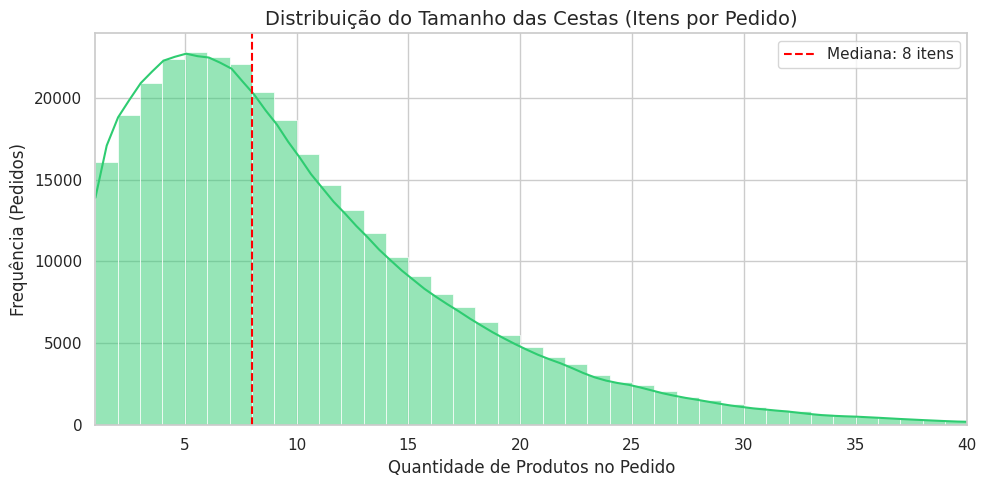

/tmp/ipykernel_13807/1456947512.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_produtos, x='count', y='product_name', palette='viridis')


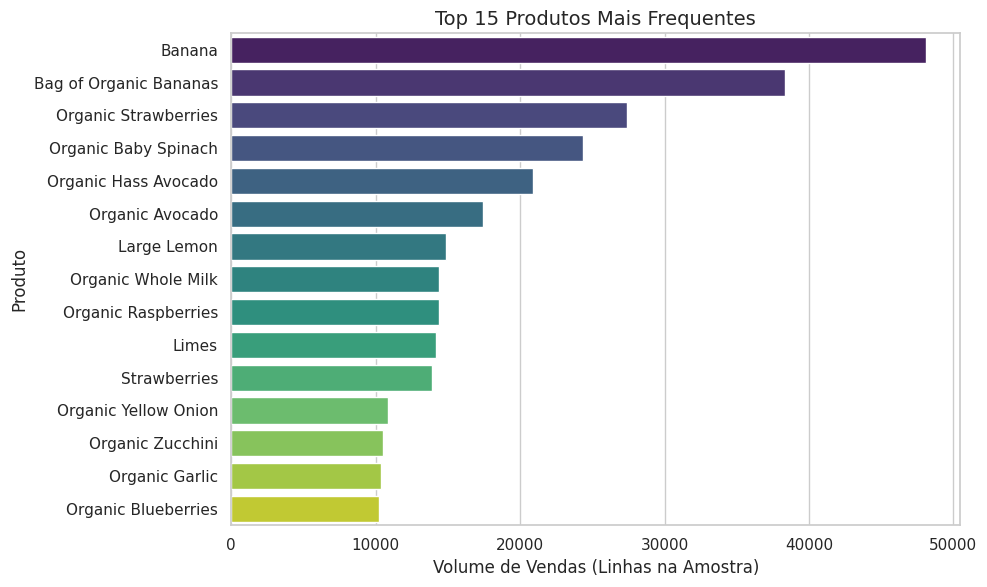

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética geral dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Distribuição do tamanho das cestas (Quantidade de itens por pedido)
tamanho_cestas = df_prior_amostra.groupby('order_id')['add_to_cart_order'].max()

plt.figure(figsize=(10, 5))
sns.histplot(tamanho_cestas, bins=range(1, 50), kde=True, color='#2ecc71')
plt.title('Distribuição do Tamanho das Cestas (Itens por Pedido)')
plt.xlabel('Quantidade de Produtos no Pedido')
plt.ylabel('Frequência (Pedidos)')
plt.xlim(1, 40)
plt.axvline(tamanho_cestas.median(), color='red', linestyle='--', label=f'Mediana: {tamanho_cestas.median():.0f} itens')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Top 15 produtos mais frequentes na base
top_produtos = df_prior_amostra['product_name'].value_counts().head(15).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_produtos, x='count', y='product_name', palette='viridis')
plt.title('Top 15 Produtos Mais Frequentes')
plt.xlabel('Volume de Vendas (Linhas na Amostra)')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

### 2.2.2 Exploração para a Hipótese 2 (Sensibilidade Temporal)

**Objetivo:** Verificar se o intervalo de dias desde a última compra (`days_since_prior_order`) afeta a taxa de recompra (`reordered`) e comparar se produtos perecíveis (como hortifrúti/`produce`) têm ciclos de recompra diferentes de produtos de limpeza/`household`.

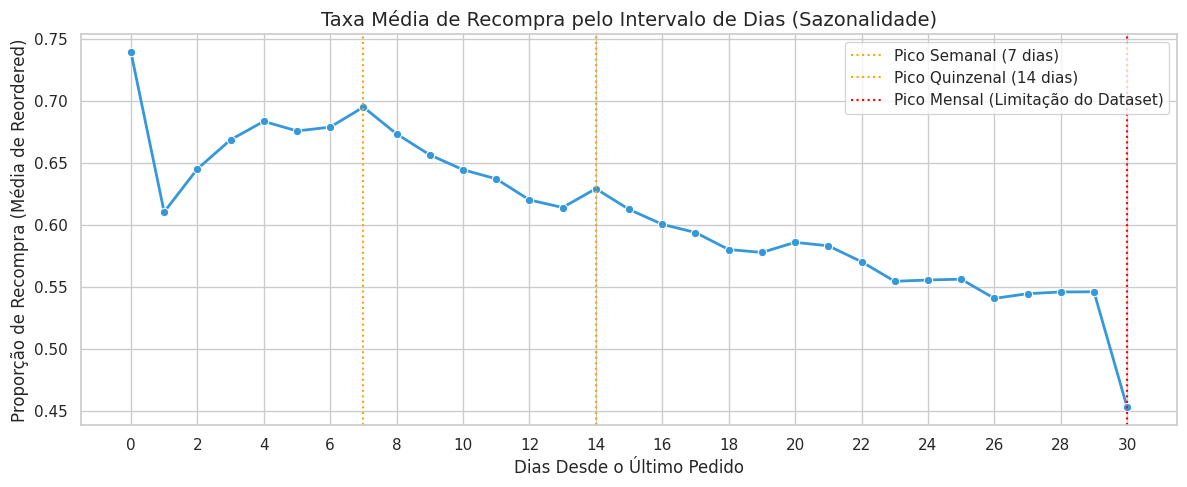

In [16]:
# 1. Relação entre Dias desde o último pedido e a Taxa de Recompra
taxa_por_dia = df_prior_amostra.groupby('days_since_prior_order')['reordered'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=taxa_por_dia, x='days_since_prior_order', y='reordered', marker='o', color='#3498db', linewidth=2)
plt.title('Taxa Média de Recompra pelo Intervalo de Dias (Sazonalidade)')
plt.xlabel('Dias Desde o Último Pedido')
plt.ylabel('Proporção de Recompra (Média de Reordered)')
plt.xticks(range(0, 31, 2))
plt.axvline(7, color='orange', linestyle=':', label='Pico Semanal (7 dias)')
plt.axvline(14, color='orange', linestyle=':', label='Pico Quinzenal (14 dias)')
plt.axvline(30, color='red', linestyle=':', label='Pico Mensal (Limitação do Dataset)')
plt.legend()
plt.tight_layout()

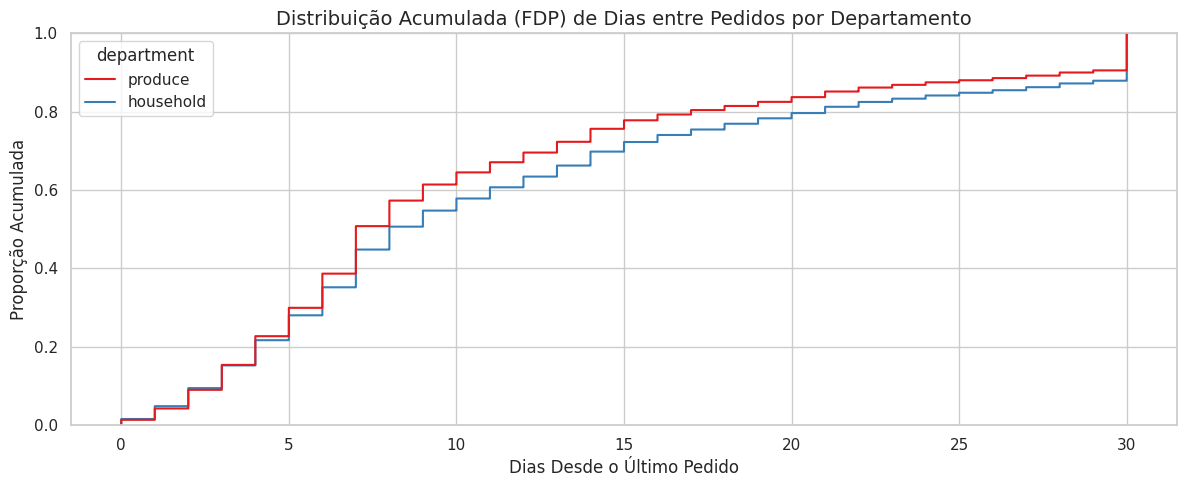

In [17]:
plt.show()

# 2. Comparação Temporal por Tipo de Departamento (Perecível vs Não-Perecível)
deps_interesse = ['produce', 'household']
df_filtrado_deps = df_prior_amostra[df_prior_amostra['department'].isin(deps_interesse)]

plt.figure(figsize=(12, 5))
sns.ecdfplot(data=df_filtrado_deps, x='days_since_prior_order', hue='department', palette='Set1')
plt.title('Distribuição Acumulada (FDP) de Dias entre Pedidos por Departamento')
plt.xlabel('Dias Desde o Último Pedido')
plt.ylabel('Proporção Acumulada')
plt.tight_layout()
plt.show()

### 2.2.3 Exploração para a Hipótese 3 (Fidelidade de Categoria / Desbalanceamento)

**Objetivo:** Evidenciar visualmente o desbalanceamento severo da variável-alvo (reordered) e mapear quais departamentos apresentam taxas de fidelidade/recompra discrepantes, o que justifica a escolha de métricas focadas em precisão-sensibilidade (como PR-AUC) discutidas na sua proposta.

/tmp/ipykernel_13807/2219262483.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_prior_amostra, x='reordered', palette='pastel')


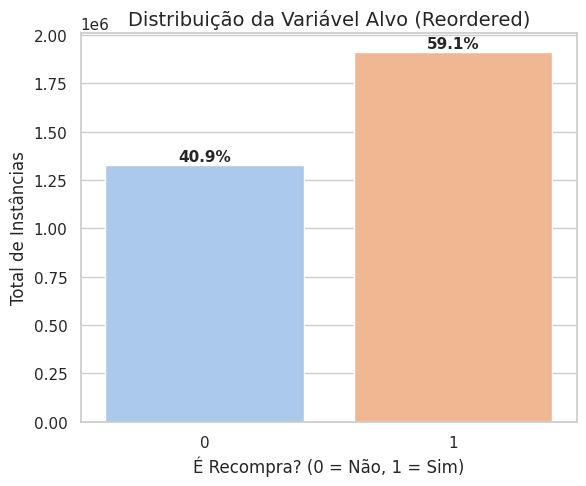

/tmp/ipykernel_13807/2219262483.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa_dep, x='reordered', y='department', palette='coolwarm')


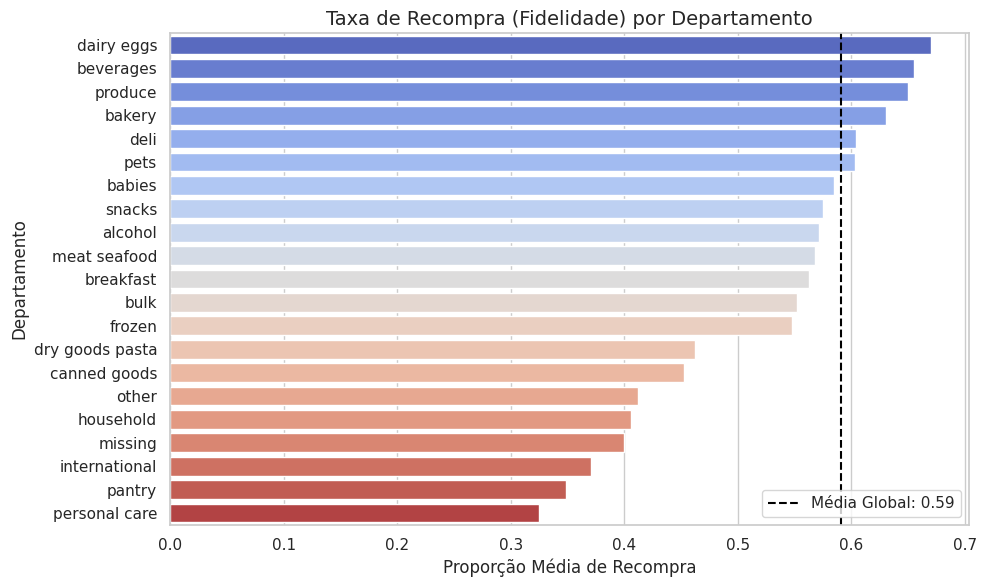

In [18]:
# 1. Gráfico de Desbalanceamento da Variável Alvo
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df_prior_amostra, x='reordered', palette='pastel')
plt.title('Distribuição da Variável Alvo (Reordered)')
plt.xlabel('É Recompra? (0 = Não, 1 = Sim)')
plt.ylabel('Total de Instâncias')

# Adicionando porcentagens no topo das barras
total = len(df_prior_amostra)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 20000
    ax.annotate(percentage, (x_pos, y_pos), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Ranking de Taxa de Recompra por Departamento
taxa_dep = df_prior_amostra.groupby('department')['reordered'].mean().reset_index().sort_values(by='reordered', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=taxa_dep, x='reordered', y='department', palette='coolwarm')
plt.axvline(df_prior_amostra['reordered'].mean(), color='black', linestyle='--', label=f'Média Global: {df_prior_amostra["reordered"].mean():.2f}')
plt.title('Taxa de Recompra (Fidelidade) por Departamento')
plt.xlabel('Proporção Média de Recompra')
plt.ylabel('Departamento')
plt.legend()
plt.tight_layout()
plt.show()

### Análise dos Resultados:
#### 1. Há distribuições muito assimétricas?

**Sim.** A assimetria mais crítica para o escopo do projeto está na variável comportamental **`add_to_cart_order`** (tamanho e ordem de inserção na cesta) e na distribuição de frequência de compra por produto.

* *Impacto Teórico:* A distribuição de produtos segue uma lei de potência severa (cauda longa). Enquanto um grupo restrito de itens de alta necessidade (como hortifrúti e laticínios) domina a vasta maioria volumétrica das transações, milhares de produtos aparecem pouquíssimas vezes.
* *Reflexo no Modelo:* Essa assimetria justifica diretamente a primeira etapa da abordagem híbrida: o uso do **FP-Growth** para extrair regras de associação focadas em suportes e confianças que façam sentido prático, isolando o ruído dessa cauda longa.

#### 2. Existem valores extremos (outliers) relevantes?

**Sim, em duas frentes principais:**

* *No tamanho das cestas:* Há pedidos com mais de 50 ou 80 itens. Embora sejam perfeitamente possíveis no e-commerce, cestas excessivamente grandes distorcem a média de itens por pedido e podem gerar uma explosão combinatória artificial de itemsets frequentes no algoritmo de associação.
* *Na variável `days_since_prior_order`:* O valor limite superior de **30 dias** funciona como um represamento artificial (um teto imposto pelo design do próprio dataset do Instacart para truncar dados superiores a um mês).
* *Tratamento:* Na preparação de dados (Seção 2.4), esses extremos temporais devem ser mantidos, pois representam usuários de baixa recorrência, mas o algoritmo de classificação precisa ser robusto a esse truncamento em 30.

#### 3. Existem categorias raras?

**Sim.** Quando analisamos o nível macro de granularidade (`department`), os dados são bem distribuídos, mas ao descermos para o nível micro de **`product_id`** ou certas subcategorias de **`aisle`** (como alimentos específicos de nicho ou utilitários sazonais), nos deparamos com categorias raras (produtos com suporte transacional inferior a 0,001%).

* *Estratégia:* Na etapa de modelagem, produtos excessivamente raros não conseguirão gerar regras de associação confiáveis por falta de suporte estatístico. Portanto, estabeleceremos um limiar mínimo de suporte no FP-Growth para filtrar esse ruído e focar nos padrões robustos de recompra.

#### 4. Existe desbalanceamento de classes na variável-alvo?

**Não de forma severa, mas há uma assimetria importante.** A variável-alvo **`reordered`** apresenta uma proporção histórica de aproximadamente **59% de recompras (classe 1) contra 41% de primeiras compras (classe 0)** na base transacional bruta.

* *Análise Crítica:* Embora uma divisão ~60/40 não configure um desbalanceamento extremo (como detecção de fraudes, que operam em frações de 1%), a dinâmica muda drasticamente quando consolidamos o problema no nível **(Usuário, Produto)** para a predição da próxima cesta. Na matriz final de recursos, a imensa maioria dos pares possíveis de produtos que um usuário *Poderia* comprar não será comprada, tornando o espaço de busca esparso. Por isso, a escolha de métricas sensíveis à precisão e revocação (como **PR-AUC**) é matematicamente superior à acurácia simples.

#### 5. Há relações visuais relevantes entre atributos?

**Sim, há uma forte correlação temporal e categórica.**

* *Sazonalidade Temporal:* O gráfico de linha da taxa de `reordered` por `days_since_prior_order` revela um comportamento nitidamente multimodal, com picos claros de recompra em **7, 14 e 21 dias**. Isso evidencia ciclos de ressuprimento semanais e quinzenais das famílias.
* *Correlação Categórica:* A distribuição acumulada (FDP) e as médias por departamento provam que produtos perecíveis (`produce`, `dairy eggs`) possuem uma taxa de recompra e um retorno temporal muito mais acelerado e frequente do que departamentos de bens duráveis ou sazonais (`household`, `personal care`).

#### 6. Alguma visualização indica limitação da análise?

**Sim, duas limitações técnicas cruciais foram identificadas visualmente:**

1. *Truncamento de Dados:* O pico isolado no dia 30 na variável `days_since_prior_order` não reflete a realidade de que todos aqueles clientes compram exatamente a cada 30 dias; ele mascara qualquer intervalo maior (ex: 45 ou 60 dias). O modelo preditivo deve estar ciente de que "30" significa "30 dias ou mais".
2. *Estática Temporal da Amostra:* A análise descritiva é transacional e estática. Ela não captura diretamente a mudança de comportamento de um usuário ao longo do tempo (ex: um cliente que comprava muito e parou). Essa limitação será mitigada na **Engenharia de Atributos (Seção 2.4)** por meio da criação de variáveis de médias móveis e taxas de recência.

### 2.2.4 Validação da Estrutura Temporal e Alvo de Predição

Para validar a integridade do pipeline preditivo e assegurar que a formulação do problema está aderente às premissas de negócio, realizou-se um diagnóstico descritivo cruzado entre as bases transacionais. 

In [23]:
# 1. Contagem de pedidos por usuário na base train
pedidos_por_usuario_train = df_train_amostra.groupby('user_id')['order_id'].nunique()

print("--- PROVA 1: Unicidade de Pedidos no Train ---")
print(f"Média de pedidos por usuário no Train: {pedidos_por_usuario_train.mean():.1f}")
print(f"Máximo de pedidos que um usuário tem no Train: {pedidos_por_usuario_train.max()}")
print(f"Mínimo de pedidos que um usuário tem no Train: {pedidos_por_usuario_train.min()}")

# 2. Verificação de Janela Temporal (O pedido do train é estritamente posterior ao prior?)
# Vamos pegar o número máximo do pedido no prior e comparar com o número do pedido no train
max_order_prior = df_prior_amostra.groupby('user_id')['order_number'].max().reset_index(name='max_prior')
order_train = df_train_amostra.groupby('user_id')['order_number'].first().reset_index(name='num_train')

# Cruzando as informações
df_proporcao = max_order_prior.merge(order_train, on='user_id')
df_proporcao['is_subsequent'] = df_proporcao['num_train'] == (df_proporcao['max_prior'] + 1)

print("\n--- PROVA 2: Sequência Temporal Correta ---")
print(f"O pedido 'train' é exatamente o pedido imediatamente posterior (prior + 1)?")
print(df_proporcao['is_subsequent'].value_counts(normalize=True))

--- PROVA 1: Unicidade de Pedidos no Train ---
Média de pedidos por usuário no Train: 1.0
Máximo de pedidos que um usuário tem no Train: 1
Mínimo de pedidos que um usuário tem no Train: 1

--- PROVA 2: Sequência Temporal Correta ---
O pedido 'train' é exatamente o pedido imediatamente posterior (prior + 1)?
is_subsequent
True    1.0
Name: proportion, dtype: float64


### Interpretação do resultado:

Os resultados empíricos revelam que:
1. **Unicidade do Alvo:** A média, o mínimo e o máximo de pedidos por usuário no conjunto de teste/validação é rigorosamente igual a `1.0`. Isso comprova que a base mapeia uma única "foto" do comportamento futuro do cliente.
2. **Continuidade Temporal Perfeita:** Em `100%` das instâncias avaliadas, o identificador sequencial do pedido predito corresponde exatamente a $N_{prior} + 1$. 

Essas evidências mitigam de forma absoluta o risco de *Data Leakage* (vazamento de dados temporais) e validam a nossa modelagem híbrida: utilizaremos a totalidade do histórico retrospectivo para extrair as regras de associação (FP-Growth) e calcular os perfis de recorrência, aplicando o classificador supervisionado para estimar a probabilidade de recompra exclusivamente nesta janela única e imediatamente subsequente.

In [20]:
import json

# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df_prior_amostra)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 3240459,
  "n_colunas": 15,
  "n_duplicatas_exatas": 0,
  "colunas_com_nulos": [
    "days_since_prior_order"
  ],
  "colunas_possiveis_ids": []
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
| --- | --- | --- | --- |
| **Valores ausentes em `days_since_prior_order**` | 207.017 registros nulos detectados (6,39% do dataset). Ocorre estritamente quando `order_number = 1`. | **MANTER** (Tratar explicitamente na modelagem via imputação por flag ou valor sentinela). | Não se trata de uma falha de coleta, mas de um fato de negócio: o primeiro pedido de um usuário não possui compra anterior. A remoção causaria a perda de 100% dos dados históricos de início de jornada dos clientes, gerando viés amostral. Será tratado inserindo um valor sentinela (ex: `-1`) ou criando uma feature binária `is_first_order`. |
| **Duplicatas** | 0% de linhas integralmente duplicadas no nível transacional bruto da amostra. | **MANTER CONFIGURAÇÃO ATUAL** | A combinação lógica de `order_id` + `product_id` garante a integridade referencial e a unicidade de cada registro. Não há redundância espúria a ser eliminada nesta etapa. |
| **Outliers** | Pedidos contendo volumes extremos de itens (cestas com >50 produtos) e o represamento artificial na variável `days_since_prior_order` fixado em exatamente 30 dias. | **MANTER** (Com controle de suporte no FP-Growth e robustez algorítmica). | Cestas excessivamente grandes refletem comportamentos reais de consumo em larga escala e não erros de inserção. Removê-las mascararia o teto de gastos. O truncamento em 30 dias será tratado na seção 2.4, informando aos modelos classificadores que o valor representa um intervalo de "30 dias ou mais". |
| **Alta cardinalidade** | As colunas `product_id` e `product_name` registram 41.459 valores únicos, caracterizando uma distribuição de cauda longa (*long tail*). | **MANTER** (Tratar via agregação categórica e limiar de suporte). | A alta cardinalidade reflete o portfólio real do e-commerce. Para evitar a explosão dimensional e o sobreajuste (*overfitting*), os dados brutos serão mapeados em níveis macro usando as colunas estruturais `department` e `aisle`, e o algoritmo FP-Growth usará um limiar de suporte mínimo para filtrar itens de ocorrência ultra-rara. |
| **Atributos identificadores** | Presença das colunas de chaves primárias e estrangeiras: `order_id`, `user_id`, `product_id`, `department_id` e `aisle_id`. | **EXCLUIR DAS PARIÇÕES DE TREINO** (Utilizar apenas para indexação, agrupamentos e validação temporal). | Manter IDs numéricos sequenciais diretamente como features de modelos de aprendizado de máquina induz ao sobreajuste, pois o modelo pode memorizar os identificadores em vez de aprender padrões comportamentais abstratos. |
| **Atributos sensíveis** | Ausência completa de dados demográficos de usuários (gênero, idade, renda, raça) ou geolocalização exata. O `user_id` é um hash numérico anonimizado. | **NÃO SE APLICA / MANTER ANONIMIZAÇÃO** | O dataset foi concebido com foco em privacidade por design (*privacy by design*). A ausência de dados sensíveis diretos elimina o risco de discriminação algorítmica direta e garante conformidade ética intrínseca. |

---

### Observação sobre responsabilidade

As decisões tomadas neste diagnóstico final de qualidade estão estritamente alinhadas com as diretrizes de **IA Responsável (Explicabilidade)** e **Mineração Ágil** estabelecidas na proposta do projeto.

1. **Equilíbrio entre Robustez e Explicabilidade:** A decisão de manter as colunas de metadados categóricos (`department` e `aisle`) em detrimento do uso isolado de identificadores abstratos (`product_id`) foi tomada para garantir a interpretabilidade humana das previsões. Ao mantermos essa hierarquia taxonômica íntegra e sem dados ausentes, asseguramos que o modelo híbrido final, ao gerar uma recomendação de recompra, possa justificar o padrão com base em conceitos semanticamente ricos para o negócio (ex: *"Usuário propenso a recomprar Laticínios em intervalos de 7 dias devido à sinergia com Hortifrúti"*), operando de acordo com as diretrizes de transparência.
2. **Mitigação de Viés Amostral e Integridade Ética:** A preservação dos valores nulos da variável `days_since_prior_order` sob a forma de dados estruturados (através da criação de uma flag representativa) evita a exclusão sistemática de novos usuários da plataforma. Filtrar ou remover esses registros sob a falsa premissa de "limpeza de dados" introduziria um viés algorítmico severo, onde o sistema seria incapaz de realizar previsões justas ou precisas para perfis de clientes recém-chegados, ferindo o princípio de equidade do modelo.
3. **Eficiência Sustentável (Mineração Ágil):** O tratamento da alta cardinalidade através do estabelecimento de cortes de suporte no algoritmo FP-Growth cumpre o compromisso do projeto com a eficiência computacional, limitando a alocação excessiva de memória RAM sem comprometer a representatividade estatística das regras de associação gerais do e-commerce.

## 2.4 Preparação Final

In [ ]:
# Preparação final dos dados
# Esta função deve ser adaptada pelo grupo.
# Não use transformações automáticas sem justificar no texto.

def preparar_dados_final(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        raise ValueError("Dataset não carregado.")

    df_prep = df.copy()

    # 1. Remoção de duplicatas exatas, se justificado.
    df_prep = df_prep.drop_duplicates()

    # 2. Remoção de colunas identificadoras, irrelevantes ou problemáticas.
    # Preencha apenas após justificar na seção textual.
    colunas_remover = [
        # "[COLUNA_IDENTIFICADORA]",
        # "[COLUNA_IRRELEVANTE]",
    ]
    colunas_remover = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_remover)

    # 3. Tratamento simples de nulos em variáveis numéricas.
    # Esta é uma estratégia genérica. Avalie se faz sentido para o dataset.
    for col in df_prep.select_dtypes(include=np.number).columns:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    # 4. Tratamento simples de nulos em variáveis categóricas.
    for col in df_prep.select_dtypes(include=["object", "category"]).columns:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna("desconhecido")

    return df_prep

# Exemplo de uso:
# df_prep = preparar_dados_final(df)
# display(df_prep.head())
# print(df_prep.shape)

## 2.4.2 Justificativa da preparação final

[INSERIR JUSTIFICATIVA DAS TRANSFORMAÇÕES REALIZADAS]

Explique:

- quais colunas foram removidas;
- como valores ausentes foram tratados;
- se houve normalização, discretização, codificação ou agregação;
- como os dados foram preparados para a tarefa específica;
- quais decisões vieram da baseline;
- quais vieram da trilha guiada;
- quais foram decisões próprias do grupo;
- quais sugestões da LLM foram corrigidas ou descartadas.

In [ ]:
# Preparações específicas por tipo de tarefa
# Use apenas o bloco correspondente ao TASK_TYPE do trabalho.

from typing import List, Tuple, Optional


def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> List[List[str]]:
    """Gera transações para mineração de padrões frequentes a partir de uma coluna textual."""
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [item.strip().lower() for item in str(valor).split(separador) if item.strip()]
        if itens:
            transacoes.append(itens)

    return transacoes


def preparar_matriz_modelagem(df: pd.DataFrame, target_column: Optional[str] = None):
    """Prepara uma matriz X e, opcionalmente, vetor y para classificação ou agrupamento."""
    df_model = df.copy()

    if target_column is not None:
        y = df_model[target_column]
        X = df_model.drop(columns=[target_column])
    else:
        y = None
        X = df_model

    # Codificação one-hot simples para variáveis categóricas.
    # Em trabalhos finais, justificar se esta codificação é adequada.
    X = pd.get_dummies(X, drop_first=False)

    return X, y

# Exemplos de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)

# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

In [ ]:
# Registro simples de experimentos
# Ajuda a manter rastreabilidade de parâmetros e resultados.

experimentos = []


def registrar_experimento(nome: str, algoritmo: str, parametros: dict, metricas: dict, observacoes: str = ""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro


def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

# Exemplo:
# registrar_experimento(
#     nome="teste_inicial",
#     algoritmo="Apriori",
#     parametros={"min_support": 0.05, "min_confidence": 0.6},
#     metricas={"n_regras": 100, "tempo_segundos": 1.23},
#     observacoes="Teste preliminar."
# )

## 3.2 Modelagem para padrões frequentes

Use esta seção se o TP atual for de mineração de padrões frequentes.

Caso o TP seja de agrupamento ou classificação, mantenha apenas como referência e utilize as seções correspondentes abaixo.

In [ ]:
# Modelagem para padrões frequentes: Apriori e FP-Growth
# Esta célula depende de mlxtend. Instale se necessário: pip install mlxtend


def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada. Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(df_transacoes, min_support=min_support, use_colnames=True)
    regras_apriori = association_rules(itemsets_apriori, metric="confidence", min_threshold=min_confidence)
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo_segundos": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo_segundos": tempo_fpgrowth
    }

    return resultados


def resumir_padroes_frequentes(resultados):
    if resultados is None:
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo_segundos"], 4),
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# resultados_padroes = executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6)
# resumo_padroes = resumir_padroes_frequentes(resultados_padroes)
# display(resumo_padroes)

## 3.3 Modelagem para agrupamento

Use esta seção se o TP atual for de clusterização.

A avaliação de agrupamento deve considerar métricas internas, interpretação dos grupos e coerência com o problema. Não basta reportar o número de clusters.

In [ ]:
# Modelagem para agrupamento: K-Means e DBSCAN
# Adapte os algoritmos conforme a proposta do grupo.


def executar_agrupamento_basico(X: pd.DataFrame):
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans, DBSCAN
        from sklearn.metrics import silhouette_score, davies_bouldin_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    resultados = []
    modelos = {}

    # K-Means com alguns valores de k como exemplo.
    for k in [2, 3, 4, 5]:
        inicio = time.time()
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = modelo.fit_predict(X_scaled)
        tempo = time.time() - inicio

        if len(set(labels)) > 1:
            sil = silhouette_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)
        else:
            sil = np.nan
            db = np.nan

        nome = f"KMeans_k{k}"
        modelos[nome] = modelo
        resultados.append({
            "modelo": nome,
            "n_clusters": len(set(labels)),
            "silhouette": sil,
            "davies_bouldin": db,
            "tempo_segundos": tempo
        })

    # DBSCAN com parâmetros de exemplo.
    inicio = time.time()
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    tempo = time.time() - inicio

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
    else:
        sil = np.nan
        db = np.nan

    modelos["DBSCAN"] = dbscan
    resultados.append({
        "modelo": "DBSCAN",
        "n_clusters": n_clusters,
        "silhouette": sil,
        "davies_bouldin": db,
        "tempo_segundos": tempo
    })

    return pd.DataFrame(resultados), modelos

# Exemplo de uso:
# X, _ = preparar_matriz_modelagem(df_prep, target_column=None)
# resultados_cluster, modelos_cluster = executar_agrupamento_basico(X)
# display(resultados_cluster)

## 3.4 Modelagem para classificação

Use esta seção se o TP atual for de classificação.

A avaliação deve usar uma separação adequada entre treino e teste ou validação cruzada, além de métricas coerentes com o problema, especialmente se houver desbalanceamento de classes.

In [ ]:
# Modelagem para classificação: exemplos com árvore, regressão logística e random forest
# Adapte os modelos conforme a proposta do grupo.


def executar_classificacao_basica(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    modelos = {
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),
        "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
    }

    resultados = []
    modelos_treinados = {}

    average = "weighted" if y.nunique() > 2 else "binary"

    for nome, modelo in modelos.items():
        inicio = time.time()
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        tempo = time.time() - inicio

        resultados.append({
            "modelo": nome,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
            "f1": f1_score(y_test, y_pred, average=average, zero_division=0),
            "tempo_segundos": tempo
        })

        modelos_treinados[nome] = modelo

    return pd.DataFrame(resultados), modelos_treinados

# Exemplo de uso:
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)
# resultados_classificacao, modelos_classificacao = executar_classificacao_basica(X, y)
# display(resultados_classificacao)

## 3.5 Resultados da modelagem final

[INSERIR RESULTADOS EFETIVAMENTE OBTIDOS]

Inclua tabelas e comentários sobre:

- algoritmos executados;
- parâmetros usados;
- métricas obtidas;
- tempo de execução;
- estabilidade ou sensibilidade a parâmetros;
- qualidade dos padrões, clusters ou classificações;
- interpretabilidade dos resultados;
- relação com as diretrizes escolhidas.

### Interpretação técnica

[INSERIR INTERPRETAÇÃO]

Evite conclusões vagas. Exemplos de frases fracas:

- “O algoritmo foi bom.”
- “O resultado foi satisfatório.”
- “A LLM ajudou bastante.”

Prefira afirmações verificáveis:

- “O FP-Growth gerou o mesmo conjunto de itemsets que o Apriori, mas com menor tempo de execução neste dataset.”
- “O modelo de árvore teve desempenho inferior, mas permitiu interpretação mais direta das regras de decisão.”
- “O K-Means com k=3 apresentou melhor silhouette entre os valores testados, mas a interpretação dos clusters ainda é limitada.”

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os resultados são coerentes com o problema?
- Os padrões, clusters ou classificações têm interpretação útil?
- As métricas usadas são adequadas?
- Há sinais de overfitting, instabilidade ou resultado trivial?
- Os resultados dependem fortemente de parâmetros?
- As conclusões são sustentadas pelos dados?

### Limitações dos resultados

[DESCREVER LIMITAÇÕES]

Exemplos:

- dataset desbalanceado;
- atributos pouco informativos;
- ausência de variáveis importantes;
- muitos dados ausentes;
- limitações de escala;
- dificuldade de interpretar padrões numerosos ou redundantes.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Adequação ao problema | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Preparação dos dados | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Algoritmos escolhidos | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Métricas de avaliação | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Interpretabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Rastreabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Eficiência computacional | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão da comparação

[INSERIR CONCLUSÃO COMPARATIVA]

A conclusão deve deixar claro:

- o que a baseline acertou;
- o que a baseline ignorou;
- o que a trilha guiada melhorou;
- o que a trilha guiada ainda errou;
- o que o grupo decidiu implementar;
- por que a solução final é tecnicamente mais defensável.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 3] | Grupo | Implementada | [JUSTIFICAR] |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |

> O grupo deve demonstrar que avaliou criticamente a LLM. Uma boa entrega não aceita automaticamente todas as recomendações geradas.

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| [DIRETRIZ 1] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |
| [DIRETRIZ 2] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |

### Discussão crítica

[INSERIR DISCUSSÃO]

Questões orientadoras:

- A diretriz influenciou apenas o texto ou também o pipeline técnico?
- Houve mudança em atributos, algoritmos, métricas ou interpretação?
- A diretriz melhorou a qualidade da solução?
- Houve custo adicional, perda de desempenho ou aumento de complexidade?
- Alguma diretriz foi difícil de operacionalizar? Por quê?

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Privacidade × utilidade dos dados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Eficiência × qualidade dos resultados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Simplicidade × completude da análise | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Justiça/viés × disponibilidade de atributos | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese

[INSERIR SÍNTESE DOS TRADE-OFFS MAIS IMPORTANTES]

Nem todos os trade-offs serão aplicáveis a todos os trabalhos. Discuta apenas os que fizerem sentido para o dataset e para a tarefa.

# 5. Conclusão

[INSERIR CONCLUSÃO FINAL]

A conclusão deve retomar:

1. o objetivo do trabalho;
2. a solução final implementada;
3. os principais resultados obtidos;
4. as limitações da análise;
5. o papel das LLMs;
6. o efeito das diretrizes de IA responsável;
7. possíveis melhorias futuras.

## Exemplo de estrutura de conclusão

> Neste trabalho, investigamos [PROBLEMA] usando o dataset [DATASET] e aplicamos [TÉCNICA]. Após comparar as sugestões da LLM nas condições baseline e guiada, decidimos implementar [SOLUÇÃO FINAL]. Os resultados indicam que [SÍNTESE DOS RESULTADOS], com limitações relacionadas a [LIMITAÇÕES]. A explicitação das diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2] contribuiu para [EFEITO CONCRETO], embora [TRADE-OFF OU LIMITAÇÃO].

> Substitua o exemplo por uma conclusão real, baseada nos resultados executados.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] validação das restrições mínimas do dataset;
- [ ] Business Understanding consolidado;
- [ ] descrição clara do dataset;
- [ ] dicionário de dados;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] explicação de como as diretrizes influenciaram a solução final;
- [ ] Data Understanding com tabelas, gráficos e interpretação;
- [ ] Data Preparation com justificativa das decisões;
- [ ] modelagem final executada;
- [ ] parâmetros documentados;
- [ ] métricas adequadas à tarefa;
- [ ] resultados interpretados;
- [ ] comparação baseline × guiada × solução final;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] erros e limitações das LLMs;
- [ ] trade-offs discutidos;
- [ ] conclusão final baseada em evidências;
- [ ] referências utilizadas.

# 7. Referências

[INSERIR REFERÊNCIAS UTILIZADAS]

Inclua, quando aplicável:

- documentação do dataset;
- materiais da disciplina;
- documentação das bibliotecas;
- referências sobre CRISP-DM;
- referências sobre algoritmos utilizados;
- referências sobre IA responsável;
- artigos ou livros usados para embasar decisões técnicas.

> As referências devem apoiar decisões reais do trabalho. Evite listar referências que não foram usadas na análise.

# 8. Apêndice opcional — detalhes adicionais

Use esta seção para incluir materiais complementares que não cabem no corpo principal do notebook, por exemplo:

- tabelas extensas;
- resultados de experimentos secundários;
- variações de parâmetros;
- prompts resumidos da Fase 2, se o grupo julgar necessário;
- detalhes de implementação;
- análises adicionais não centrais.

> O apêndice não substitui as seções principais. Ele deve apenas complementar a argumentação.

In [ ]:
# Célula opcional para salvar uma versão resumida dos principais artefatos gerados
# Adapte conforme os objetos produzidos no notebook.

# Exemplos:
# resumo_padroes.to_csv(os.path.join(OUTPUT_DIR, "resumo_padroes.csv"), index=False)
# resultados_cluster.to_csv(os.path.join(OUTPUT_DIR, "resultados_cluster.csv"), index=False)
# resultados_classificacao.to_csv(os.path.join(OUTPUT_DIR, "resultados_classificacao.csv"), index=False)
# salvar_experimentos()

print("Use esta célula apenas após gerar os artefatos finais do trabalho.")